In [88]:
# libraries
import os
import copy
import pickle
import pandas as pd
import numpy as np

from lightgbm import LGBMClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score, fbeta_score

import seaborn as sns
import matplotlib.pyplot as plt

from pythonfn_prepInput_v3_1 import readInProfiles 
from pythonfn_prepInput_v3_1 import readInMetadata
from pythonfn_prepInput_v3_1 import generateModelInput

seed = 0
np.random.seed(seed)

In [89]:
dir_ = "/projects/ralab/data/projects/nucleiCAGEproject/5.EPCrisprBenchmark/"

In [3]:
#### IMPORTS, SETUP, AND MANAGE DF ####

In [4]:
# 0. import profiles

remove_word = ['Cap_align', 'pcr_align', 'C.csv', 'N.csv', 'N_10M', 'ProCap_pcr_1']

pos_prfl = readInProfiles(dir_ + "EPC_k562.repSub.combined.CTSSs/profiles_subtnorm/pos/", setName="EPC-pos profiles", withoutWord=remove_word)
pos_prfl.reset_index(inplace=True, drop=True)

neg_prfl = readInProfiles(dir_ + "EPC_k562.repSub.combined.CTSSs/profiles_subtnorm/neg/", setName="EPC-neg profiles", withoutWord=remove_word)
neg_prfl.reset_index(inplace=True, drop=True)

pos_count = readInProfiles(dir_ + "EPC_k562.repSub.combined.CTSSs/profiles/pos/", setName="EPC-pos counts", withoutWord=remove_word)
neg_count = readInProfiles(dir_ + "EPC_k562.repSub.combined.CTSSs/profiles/neg/", setName="EPC-neg counts", withoutWord=remove_word)

EPC-pos profiles
profiles_pos.K562_10M_N1.csv contains 429 rows
profiles_pos.K562_10M_N2.csv contains 429 rows
profiles_pos.K562_10M_N3.csv contains 429 rows
profiles_pos.K562_C1.csv contains 429 rows
profiles_pos.K562_C2.csv contains 429 rows
profiles_pos.K562_C3.csv contains 429 rows
profiles_pos.K562_N4.csv contains 429 rows
profiles_pos.K562_N5.csv contains 429 rows
profiles_pos.K562_N6.csv contains 429 rows
profiles_pos.K562_ProCap_pcr_2.csv contains 429 rows
profiles_pos.K562_groCap_1.csv contains 429 rows
In total, the dataset contains 4719 rows 

EPC-neg profiles
profiles_neg.K562_10M_N1.csv contains 3448 rows
profiles_neg.K562_10M_N2.csv contains 3448 rows
profiles_neg.K562_10M_N3.csv contains 3448 rows
profiles_neg.K562_C1.csv contains 3448 rows
profiles_neg.K562_C2.csv contains 3448 rows
profiles_neg.K562_C3.csv contains 3448 rows
profiles_neg.K562_N4.csv contains 3448 rows
profiles_neg.K562_N5.csv contains 3448 rows
profiles_neg.K562_N6.csv contains 3448 rows
profiles_neg.K

In [5]:
# make sure that it's the same order as count input data
prfl_order = ['10MN1', '10MN2', '10MN3', 'C1', 'C2', 'C3', 
              'N4', 'N5', 'N6', 'PC2', 'GC1']

In [6]:
# 1. import EPC position info .csv
pos_csv = pd.read_csv(dir_ + "1.EPC.DHS.eQTL.pos.csv")
pos_csv = pos_csv.drop(pos_csv.columns[0], axis=1)
neg_csv = pd.read_csv(dir_ + "1.EPC.DHS.eQTL.neg.csv")
neg_csv = neg_csv.drop(neg_csv.columns[0], axis=1)

In [7]:
# 2. count 

In [8]:
def countsum(csv_, count_, countsumcol_):
    newcount = copy.deepcopy(count_)
    newcsv = copy.deepcopy(csv_)
    
    newcount['RowSums'] = newcount.sum(axis=1)
    ls = []
    for i in range(len(newcsv)):
        ls.append(list(newcount.loc[i]['RowSums']))

    ls_df = pd.DataFrame(ls, columns=countsumcol_)
    newcsv['countsum_all'] = ls_df.sum(axis=1)
    return(newcsv, ls_df)

In [9]:
# countsum 
pos_csv, pos_countsum = countsum(pos_csv, pos_count, prfl_order)
neg_csv, neg_countsum = countsum(neg_csv, neg_count, prfl_order)

In [10]:
# 3. yproba

In [11]:
# load models
filename = 'model_Meena_v2_fullModel_all.sav'
model = pickle.load(open(filename, 'rb'))

In [12]:
pos_prfl_np = pos_prfl.to_numpy()
neg_prfl_np = neg_prfl.to_numpy()

In [13]:
# prediction
y_proba_pos = model.predict_proba(pos_prfl_np)
y_proba_neg = model.predict_proba(neg_prfl_np)

In [14]:
# create probability df
def proba(csv, y_proba, y_proba_col): 
    loop_ls = list(range(0, len(y_proba)+1, len(csv)))
    df = pd.DataFrame()
    for i in range(len(y_proba_col)):
        tmp = y_proba[(loop_ls[i]):(loop_ls[i+1]), 1]
        df[y_proba_col[i]] = tmp
    return(df)

In [15]:
# yproba
pos_yproba = proba(pos_csv, y_proba_pos, prfl_order)
neg_yproba = proba(neg_csv, y_proba_neg, prfl_order)

In [16]:
# masking values in yproba df based on conditions in countsum df
pos_mask = pos_countsum <= 1
neg_mask = neg_countsum <= 1

In [17]:
# masked yproba to nan
pos_yproba_masknan = pos_yproba.where(~pos_mask, np.nan)
neg_yproba_masknan = neg_yproba.where(~neg_mask, np.nan)

In [18]:
yproba_masknan = pd.concat([pos_yproba_masknan, neg_yproba_masknan], ignore_index=True)

In [19]:
# masked yproba to -1
pos_yproba_maskm1 = pos_yproba.where(~pos_mask, -1)
neg_yproba_maskm1 = neg_yproba.where(~neg_mask, -1)

In [20]:
yproba_maskm1 = pd.concat([pos_yproba_maskm1, neg_yproba_maskm1], ignore_index=True)

In [21]:
# 4. dl

In [22]:
# import DLs .csv
pos_dl = pd.read_csv(dir_ + "3.pos.DLrepSub.csv")
neg_dl = pd.read_csv(dir_ + "3.neg.DLrepSub.csv")

In [23]:
prfl_absdir = {'absdir.K562_C1':'C1', 'absdir.K562_C2':'C2', 'absdir.K562_C3':'C3',
               'absdir.K562_N4':'N4', 'absdir.K562_N5':'N5', 'absdir.K562_N6':'N6',
               'absdir.K562_groCap_1':'GC1', 'absdir.K562_ProCap_pcr_2':'PC2',
               'absdir.K562_10M_N1':'10MN1', 'absdir.K562_10M_N2':'10MN2', 'absdir.K562_10M_N3':'10MN3'}

In [24]:
columns_to_drop = ['absdir.K562_Cap_align', 'absdir.K562_pcr_align'] 

# drop rowname column, rename column names, reorder column for POSITIVE
pos_dl = pos_dl.drop(pos_dl.columns[0], axis=1)
pos_dl = pos_dl.drop(columns=columns_to_drop, axis=1)
pos_dl = pos_dl.rename(columns=prfl_absdir)
pos_dl = pos_dl[prfl_order]

# drop rowname column, rename column names, reorder column for NEGATIVE
neg_dl = neg_dl.drop(neg_dl.columns[0], axis=1)
neg_dl = neg_dl.drop(columns=columns_to_drop, axis=1)
neg_dl = neg_dl.rename(columns=prfl_absdir)
neg_dl = neg_dl[prfl_order]

In [25]:
dl = pd.concat([pos_dl, neg_dl], ignore_index=True)

In [26]:
# DLs mask with 1.1 # because 0s are in positive range
pos_dl_mask1 = pos_dl.fillna(1.1)
neg_dl_mask1 = neg_dl.fillna(1.1)

In [27]:
dl_mask1 = pd.concat([pos_dl_mask1, neg_dl_mask1], ignore_index=True)

In [28]:
#### OBJECTS ####

In [29]:
# csv
pos_csv
neg_csv

,seqnames,start,end,width,strand,thick,measuredGeneSymbol,Regulated,EffectSize,Significant,pValueAdjusted,txType,count.DHS,ovl.DHS,count.eQTL.neg0.01,count.eQTL.pos0.5,count.eQTL.pos0.9,ovl.eQTL0.5,ovl.eQTL0.9,countsum_all
0,chr1,3804460,3804960,501,*,3804710,LRRC47;SMIM1,False,-0.001471265;0.025676924,False,0.999918431;0.994159681,intergenic,1,True,0,0,0,NaN,NaN,418
1,chr1,4126791,4127291,501,*,4127041,SMIM1,False,0.023383787,False,0.992197132,intergenic,0,False,0,0,0,NaN,NaN,1
2,chr1,5304578,5305078,501,*,5304828,RPL22,False,0.026721884,False,0.990078871,exon,1,True,0,0,0,NaN,NaN,7
3,chr1,8197596,8198096,501,*,8197846,PARK7,False,-0.019877177,False,0.955905753,intergenic,1,True,0,0,0,NaN,NaN,112
4,chr1,8899850,8900350,501,*,8900100,PARK7,False,-0.041882396,False,0.959632967,intergenic,2,True,0,0,0,NaN,NaN,184
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3443,chrX,153853584,153854084,501,*,153853834,RPL10;EMD,False,0.046676354;0.015914761,False,0.86454388;0.995871246,intergenic,1,True,0,0,0,NaN,NaN,42
3444,chrX,154001821,154002321,501,*,154002071,SSR4;RPL10;BCAP31;MPP1;NAA10,False,-0.02168079;0.045933076;-0.060520994;0.0418509...,False,0.999918431;0.807012018;0.529512039;0.73780767...,intergenic,2,True,0,0,0,NaN,NaN,145
3445,chrX,154527069,154527569,501,*,154527319,RPL10;EMD;MPP1;NAA10;FAM3A;FUNDC2;LAGE3;UBL4A,False,0.037956142;0.022522793;0.069823805;-0.0174043...,False,0.869663193;0.999918431;0.251099642;0.816804378,intron,2,True,0,0,0,NaN,NaN,624
3446,chrX,154757390,154757890,501,*,154757640,RPL10;MPP1;NAA10,False,0.021206189;0.056091012;-0.02297122,False,0.999918431;0.914790463,intergenic,2,True,0,0,0,NaN,NaN,12


In [30]:
# make sure that it's the same order as count input data
prefer_order = ['C1', 'C2', 'C3', 
                'N4', 'N5', 'N6',
                '10MN1', '10MN2', '10MN3', 
                'GC1', 'PC2']

In [31]:
# countsum
pos_countsum = pos_countsum[prefer_order]
neg_countsum = neg_countsum[prefer_order]

pos_mask = pos_mask[prefer_order]
neg_mask = neg_mask[prefer_order]

In [32]:
# yproba
pos_yproba_masknan = pos_yproba_masknan[prefer_order]
neg_yproba_masknan = neg_yproba_masknan[prefer_order]
yproba_masknan = yproba_masknan[prefer_order]

pos_yproba_maskm1 = pos_yproba_maskm1[prefer_order]
neg_yproba_maskm1 = neg_yproba_maskm1[prefer_order]
yproba_maskm1 = yproba_maskm1[prefer_order]

In [33]:
# dl
pos_dl = pos_dl[prefer_order]
neg_dl = neg_dl[prefer_order]
dl = dl[prefer_order]

pos_dl_mask1 = pos_dl_mask1[prefer_order]
neg_dl_mask1 = neg_dl_mask1[prefer_order]
dl_mask1 = dl_mask1[prefer_order]

In [34]:
# save info
pos_csv.to_csv('4.1.pos.info.csv', index=False)
neg_csv.to_csv('4.1.neg.info.csv', index=False)

# save count
pos_countsum.to_csv('4.2.pos.count.csv', index=False)
neg_countsum.to_csv('4.2.neg.count.csv', index=False)

# save yproba
pos_yproba_masknan.to_csv('4.3.pos.proba.csv', index=False)
neg_yproba_masknan.to_csv('4.3.neg.proba.csv', index=False)

# save directionality
pos_dl.to_csv('4.4.pos.directionality.csv', index=False)
neg_dl.to_csv('4.4.neg.directionality.csv', index=False)

In [35]:
pos_yproba_TP_FN = pos_yproba_maskm1.applymap(lambda x: 'TP' if x >= 0.5 else 'FN')
neg_yproba_TN_FP = neg_yproba_maskm1.applymap(lambda x: 'TN' if x < 0.5 else 'FP')

pos_yproba_TP_FN.to_csv('4.5.pos_TP_FN.repSub.csv', index=False)
neg_yproba_TN_FP.to_csv('4.5.neg_TN_FP.repSub.csv', index=False)

In [84]:
neg_yproba_TN_FP

,C1,C2,C3,N4,N5,N6,10MN1,10MN2,10MN3,GC1,PC2
0,FP,TN,TN,FP,FP,FP,TN,FP,TN,FP,FP
1,TN,TN,TN,TN,TN,TN,TN,TN,TN,TN,TN
2,TN,TN,TN,TN,TN,TN,FP,FP,TN,TN,TN
3,FP,TN,TN,FP,TN,TN,TN,FP,FP,FP,FP
4,FP,FP,FP,FP,FP,FP,FP,FP,FP,FP,FP
...,...,...,...,...,...,...,...,...,...,...,...
3443,TN,TN,TN,FP,TN,TN,TN,TN,TN,FP,FP
3444,TN,TN,TN,FP,TN,FP,FP,FP,FP,FP,FP
3445,FP,FP,FP,FP,FP,FP,FP,FP,FP,FP,FP
3446,TN,TN,TN,TN,TN,TN,TN,TN,TN,FP,TN


In [87]:
neg_yproba_TN_FP['C2'].value_counts()

TN    2398
FP    1050
Name: C2, dtype: int64

In [85]:
neg_yproba_maskm1

,C1,C2,C3,N4,N5,N6,10MN1,10MN2,10MN3,GC1,PC2
0,0.560563,-1.000000,0.475930,0.591261,0.773494,0.740501,-1.000000,0.547775,-1.000000,0.994900,0.971686
1,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
2,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,0.567746,0.674104,-1.000000,-1.000000,-1.000000
3,0.668887,-1.000000,-1.000000,0.601832,0.456149,-1.000000,-1.000000,0.500515,0.503865,0.893346,0.780934
4,0.557717,0.649660,0.681546,0.862384,0.648896,0.863824,0.595833,0.810610,0.567595,0.986608,0.922534
...,...,...,...,...,...,...,...,...,...,...,...
3443,-1.000000,-1.000000,-1.000000,0.559724,-1.000000,-1.000000,-1.000000,0.446460,0.472072,0.608866,0.725543
3444,-1.000000,0.499967,0.499967,0.552332,0.485014,0.588137,0.569109,0.510016,0.571201,0.934510,0.895763
3445,0.693246,0.883965,0.696774,0.902963,0.907537,0.944147,0.689673,0.652525,0.564101,0.991205,0.957800
3446,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,0.643823,-1.000000


In [36]:
P = len(pos_csv)
P_ls = [1] * P

N = len(neg_csv)
N_ls = [0] * N

len_y_true = P + N
y_true = P_ls + N_ls
y_true_reverse = ([0] * P) + ([1] * N)

In [37]:
palette = ["#fee090", "#fee090", "#fee090", "#fee090", 
           "#fdae61", "#fdae61", "#fdae61", "#fdae61",
           "#d73027", "#d73027", "#d73027", "#d73027",
           "#4575b4", "#abd9e9", "#abd9e9"]

In [38]:
colors = {'C':"#fee090", 'C1':"#fee090", 'C2':"#fee090", 'C3':"#fee090", 
          'N':"#fdae61", 'N4':"#fdae61", 'N5':"#fdae61", 'N6':"#fdae61",
          '10MN1':"#d73027", '10MN2':"#d73027", '10MN3':"#d73027", '10MN':"#d73027",
          'GC1':"#4575b4", 'PC2':"#abd9e9", 'PC1':"#abd9e9"}

In [39]:
#### COUNT ####

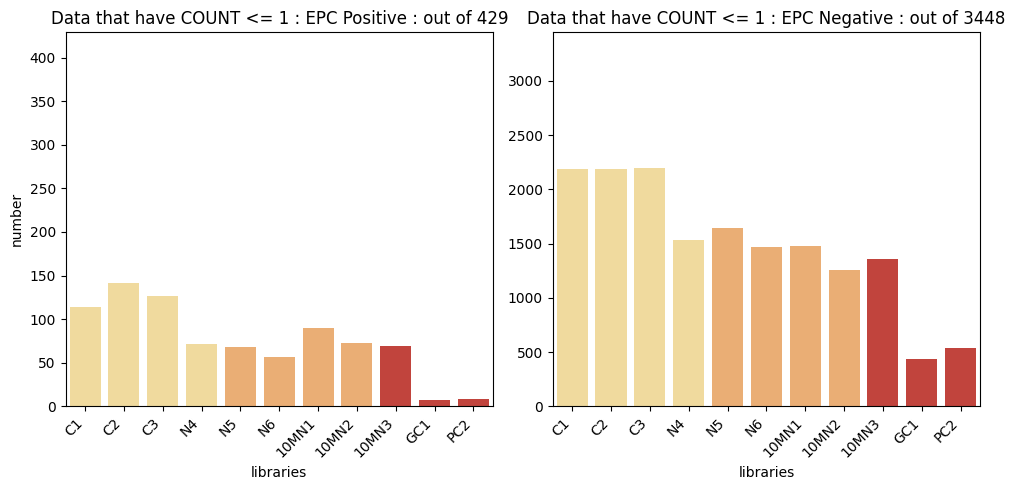

In [40]:
# FROM COUNT PROFILE, HOW MANY DATA THAT HAVE CAGE/GROCAP/PROCAP <= 1 

# Calculate column sums
pos_colsum = pos_mask.sum(axis=0)
neg_colsum = neg_mask.sum(axis=0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

# Plot positive barplot
sns.barplot(x=pos_colsum.index, y=pos_colsum.values, palette=palette, ax=ax1)
ax1.set_title('Data that have COUNT <= 1 : EPC Positive : out of ' + str(len(pos_mask)))
ax1.set_xlabel('libraries')
ax1.set_ylabel('number')
ax1.set_ylim(0, P)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha="right")

# Plot negative barplot
sns.barplot(x=neg_colsum.index, y=neg_colsum.values, palette=palette, ax=ax2)
ax2.set_title('Data that have COUNT <= 1 : EPC Negative : out of ' + str(len(neg_mask)))
ax2.set_xlabel('libraries')
#ax2.set_ylabel('number')
ax2.set_ylim(0, N)
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [41]:
#### PREDICTION ####

In [42]:
# confusion matrix on each object

def proba_confusion_matrix(df_pos, df_neg, threshold, P, N, mask):
    
    predpos = df_pos >= threshold
    TP = predpos.sum(axis=0)
    FN = P - TP
    
    cageneg_pos = df_pos == mask
    FN_cage = cageneg_pos.sum(axis=0)
    FN_pred = FN - FN_cage

    predneg = df_neg < threshold
    TN = predneg.sum(axis=0)  
    FP = N - TN
    
    cageneg_neg = df_neg == mask
    TN_cage = cageneg_neg.sum(axis=0)
    TN_pred = TN - TN_cage
    
    
    
    confusion = pd.DataFrame({'Lib': TP.index,
                              'TP': TP,
                              'FN': FN,
                              'TN': TN,
                              'FP': FP,
                              'FN_cage': FN_cage,
                              'FN_pred': FN_pred,
                              'TN_cage': TN_cage,
                              'TN_pred': TN_pred}
                              )
    
    return confusion


In [43]:
def precaision_recall(confusion):
    precision = confusion['TP'] / (confusion['TP'] + confusion['FP'])
    recall = confusion['TP'] / (confusion['TP'] + confusion['FN'])
    df = pd.DataFrame({'precision':precision,
                       'recall':recall})
    return(df)

In [44]:
def plot_confusion(confusion):
    confusion_melted = pd.melt(confusion, id_vars='Lib', var_name='Metric', value_name='Count')
    fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(16, 8))
    axes = axes.flatten()
    ylimit = [P, P, N, N, P, P, N, N]
    for i, column in enumerate(confusion.columns[1:]):  # Exclude the first column ('Lib')
        sns.barplot(x='Lib', y=column, data=confusion, ax=axes[i], palette=palette)
        axes[i].set_title(f'{column}')
        axes[i].tick_params(axis='x', rotation=45)
        axes[i].set_ylim(0, ylimit[i])
    plt.tight_layout()
    plt.show()

In [45]:
def wrap_cfs_pr_plot(df_pos, df_neg, threshole, P, N, mask):
    cfs = proba_confusion_matrix(df_pos, df_neg, threshole, P, N, mask)
    pr = precaision_recall(cfs)
    plot_confusion(cfs)
    return(cfs, pr)

In [46]:
#### VARY PROBABILITY THRESHOLD ####

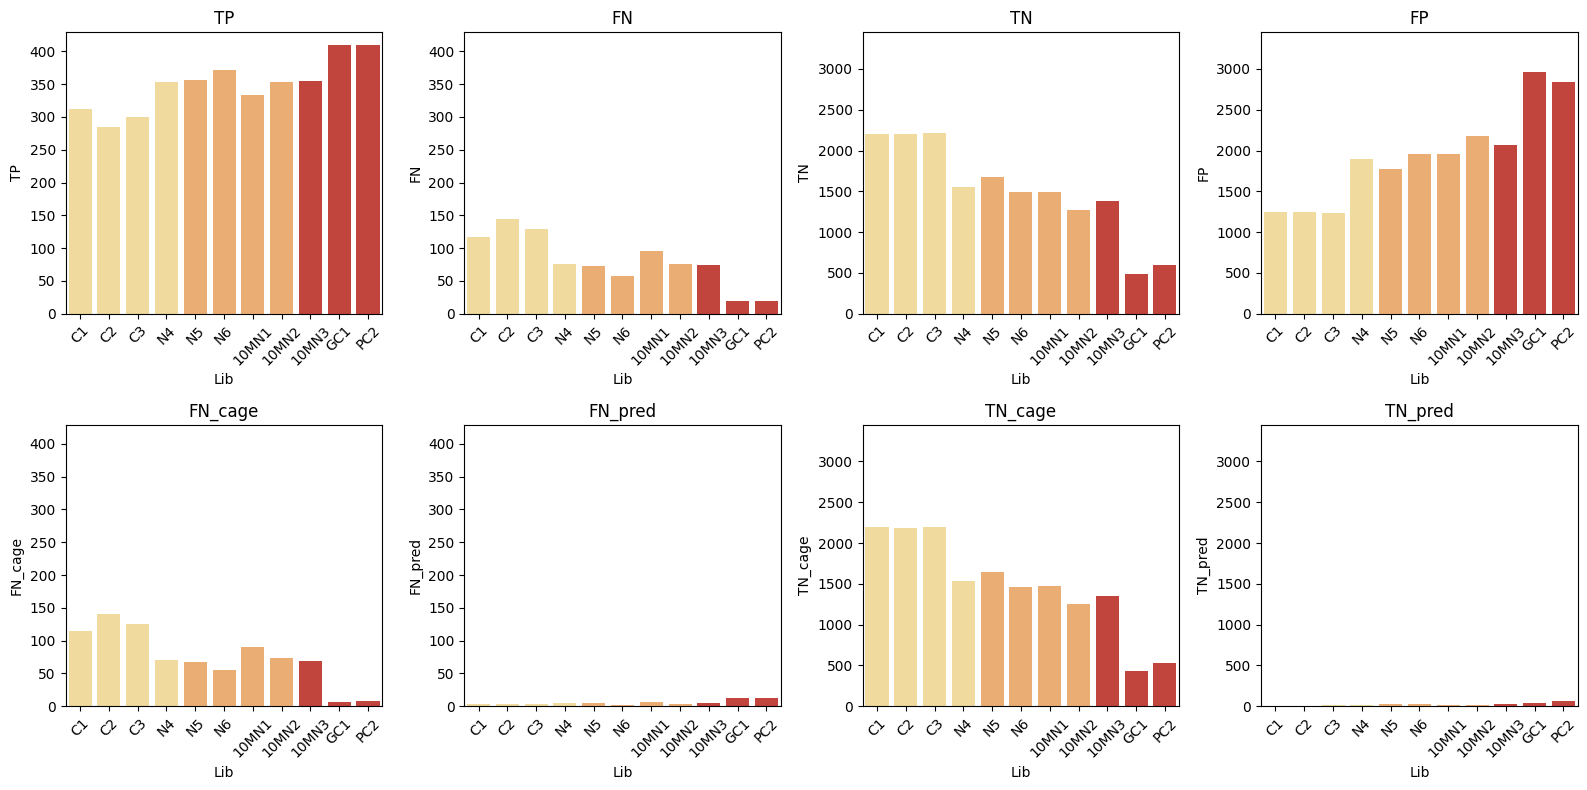

In [47]:
#### TRESHOLE=0.3 ####
cfs_yproba_maskm1_030, pr_yproba_maskm1_030 = wrap_cfs_pr_plot(pos_yproba_maskm1, neg_yproba_maskm1, 0.3, P, N, -1)

In [48]:
pr_yproba_maskm1_030.transpose()

,C1,C2,C3,N4,N5,N6,10MN1,10MN2,10MN3,GC1,PC2
precision,0.200128,0.185137,0.195440,0.156889,0.166979,0.159159,0.145478,0.139526,0.146452,0.121445,0.125691
recall,0.727273,0.662005,0.699301,0.822844,0.829837,0.864802,0.776224,0.822844,0.827506,0.955711,0.953380


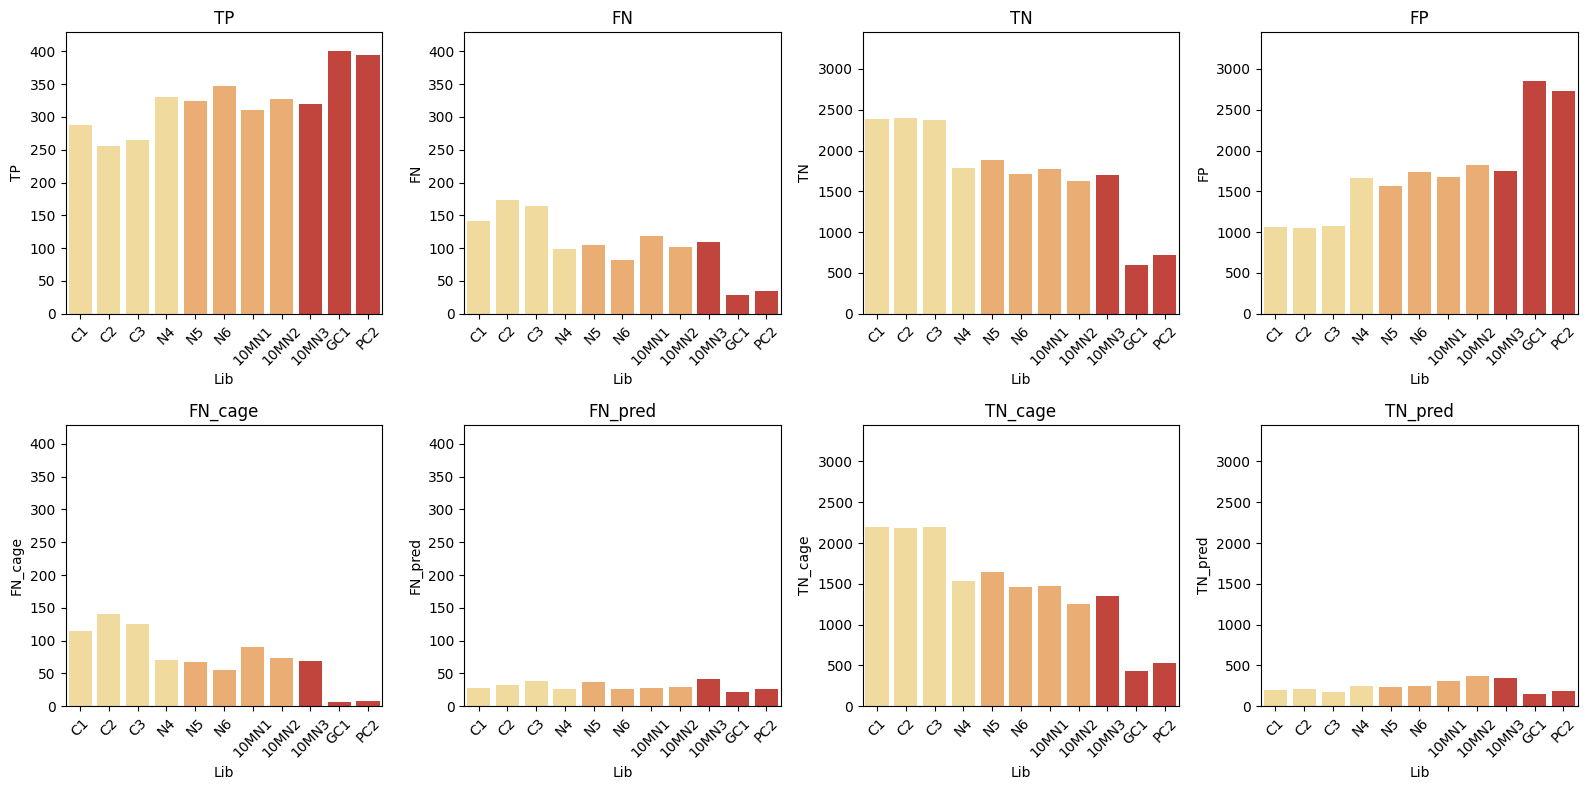

In [49]:
#### TRESHOLE=0.5 ####
cfs_yproba_maskm1_050, pr_yproba_maskm1_050 = wrap_cfs_pr_plot(pos_yproba_maskm1, neg_yproba_maskm1, 0.5, P, N, -1)

In [50]:
pr_yproba_maskm1_050.transpose()

,C1,C2,C3,N4,N5,N6,10MN1,10MN2,10MN3,GC1,PC2
precision,0.213066,0.195402,0.198057,0.165832,0.171701,0.166827,0.156991,0.152306,0.154181,0.123157,0.126400
recall,0.668998,0.594406,0.617716,0.771562,0.755245,0.808858,0.724942,0.762238,0.743590,0.934732,0.920746


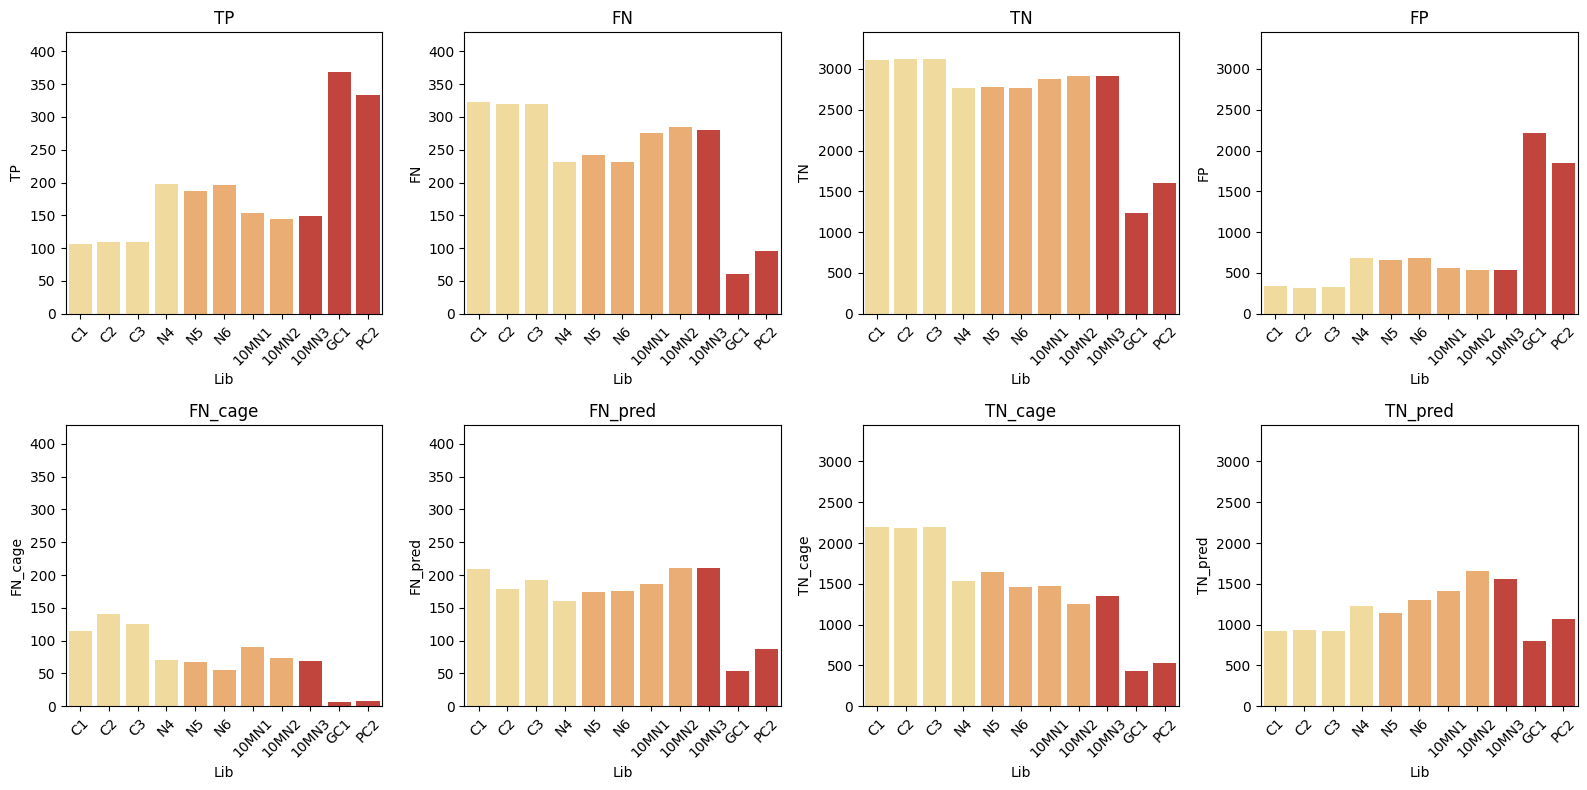

In [51]:
#### TRESHOLE=0.7 ####
cfs_yproba_maskm1_070, pr_yproba_maskm1_070 = wrap_cfs_pr_plot(pos_yproba_maskm1, neg_yproba_maskm1, 0.7, P, N, -1)

In [52]:
pr_yproba_maskm1_070.transpose()

,C1,C2,C3,N4,N5,N6,10MN1,10MN2,10MN3,GC1,PC2
precision,0.238739,0.253488,0.254042,0.223982,0.219741,0.224886,0.212796,0.212610,0.217836,0.143079,0.152682
recall,0.247086,0.254079,0.256410,0.461538,0.435897,0.459207,0.356643,0.337995,0.347319,0.860140,0.776224


In [53]:
#### ROC AND AUCROC###

In [54]:
# Plot ROC Curve
def plot_roc_df(y_true, yproba, samples):
    plt.figure(figsize=(10, 5))
    for i in samples:
        fpr, tpr, _ = roc_curve(y_true, yproba[i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{i} (AUC = {roc_auc:.2f})', color=colors[i])
        
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend()
    plt.show()
    #print(_)

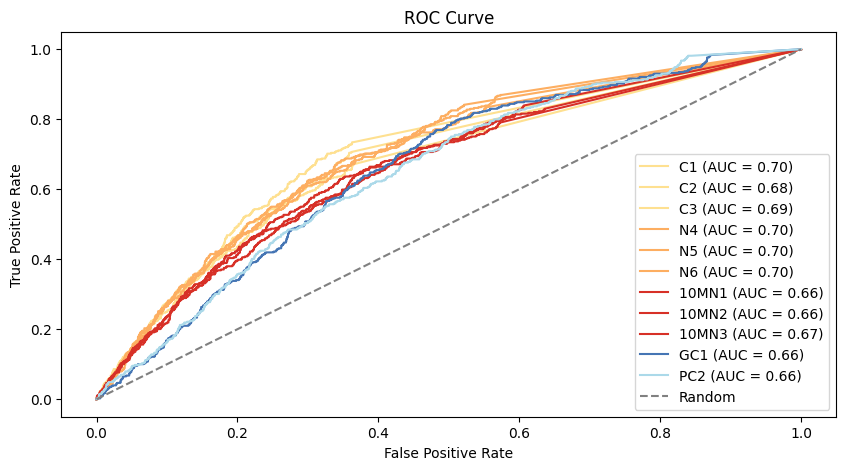

In [55]:
plot_roc_df(y_true, yproba_maskm1, prefer_order)

In [56]:
#### PR CURVE AND AUCPR ####

In [57]:
# Plot PR Curve

def plot_pr_df(y_true, yproba, samples):
    plt.figure(figsize=(10, 5))
    
    for i in samples:
        precision, recall, _ = precision_recall_curve(y_true, yproba[i])
        area_under_curve = auc(recall, precision)
        print(area_under_curve)
        plt.plot(recall, precision, label=f'{i} (AUC = {area_under_curve:.2f})', color=colors[i])
        #avg_precision = average_precision_score(y_true, yproba[i])
        #plt.plot(recall, precision, label=f'{i} (AP = {avg_precision:.2f})', color=colors[i])
    
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.legend()
    plt.show()

0.21968590783945263
0.21446411427390294
0.2110415662360962
0.20746389727494308
0.20984230848310564
0.20999804276196296
0.18903890912120022
0.19405864565656325
0.19341415096057618
0.16384570321186487
0.16719057039366172


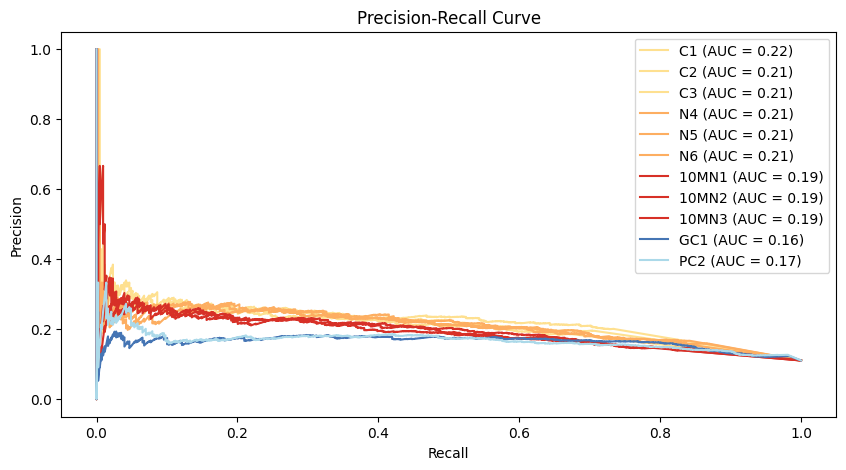

In [58]:
plot_pr_df(y_true, yproba_maskm1, prefer_order)

In [59]:
#### DIVERGENT LOCI ####

In [60]:
def dl_confusion_matrix(df_pos, df_neg, threshole, P, N, mask):
    
    predpos = df_pos < threshole
    TP = predpos.sum(axis=0)
    FN = P - TP
    
    cageneg_pos = df_pos == mask
    FN_cage = cageneg_pos.sum(axis=0)
    FN_pred = FN - FN_cage

    predneg = df_neg >= threshole
    TN = predneg.sum(axis=0)
    FP = N - TN
    
    cageneg_neg = df_neg == mask
    TN_cage = cageneg_neg.sum(axis=0)
    TN_pred = TN - TN_cage
    
    confusion = pd.DataFrame({'Lib': TP.index,
                              'TP': TP,
                              'FN': FN,
                              'TN': TN,
                              'FP': FP,
                              'FN_cage': FN_cage,
                              'FN_pred': FN_pred,
                              'TN_cage': TN_cage,
                              'TN_pred': TN_pred})
    
    return(confusion)

In [61]:
def wrap_cfs_pr_plot_dl(df_pos, df_neg, threshole, P, N, mask):
    cfs = dl_confusion_matrix(df_pos, df_neg, threshole, P, N, mask)
    pr = precaision_recall(cfs)
    plot_confusion(cfs)
    return(cfs, pr)

In [62]:
#### VARY ABS DIRECTIONALITY THRESHOLD : 0.7, 0.8, 0.9 ####

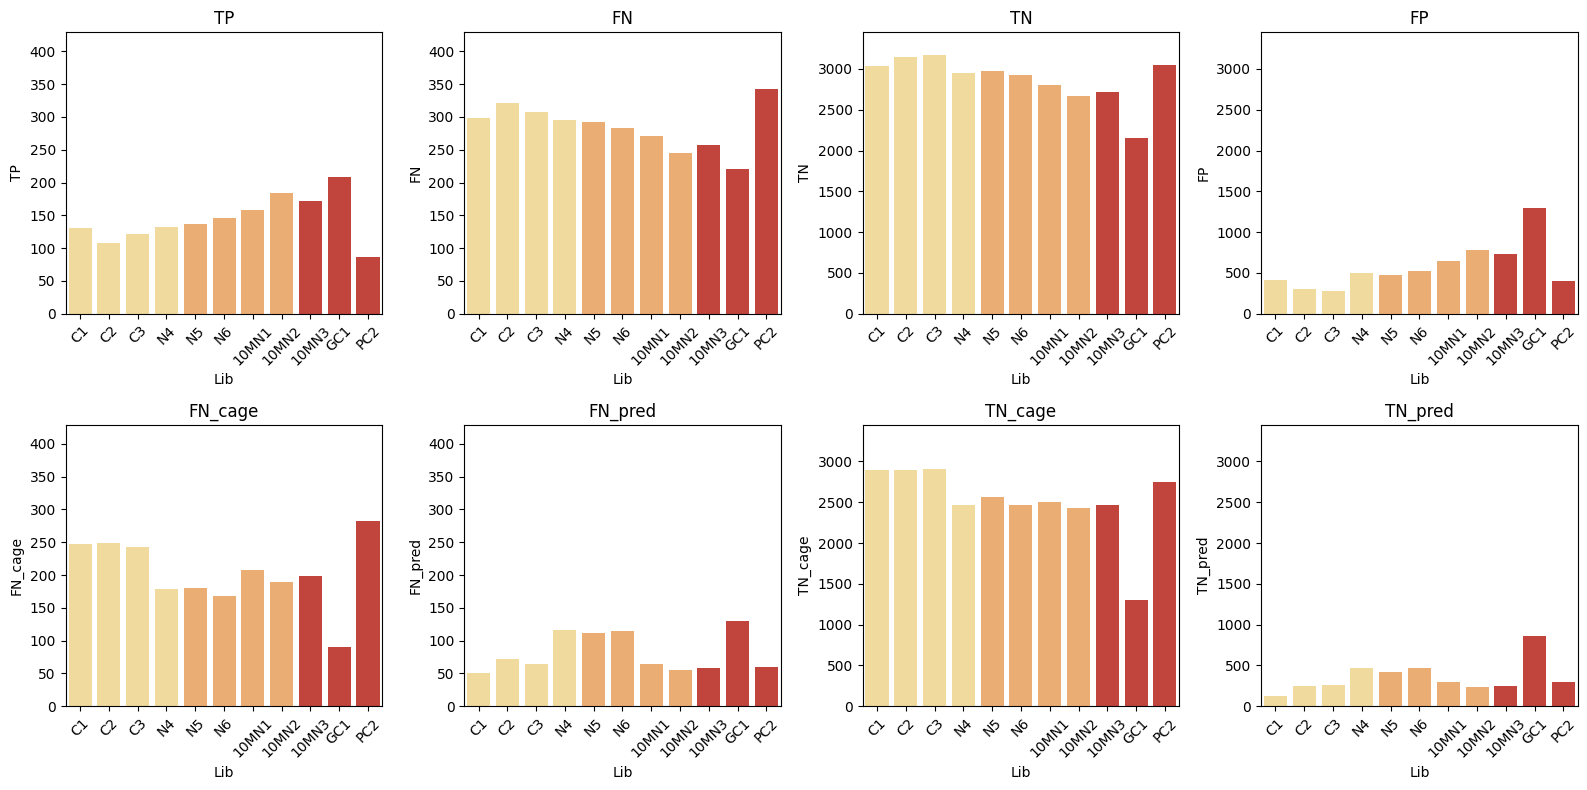

In [63]:
#### ABS DIRECTIONALITY < 0.7 ####
cfs_dl_070, pr_dl_070 = wrap_cfs_pr_plot_dl(pos_dl_mask1, neg_dl_mask1, 0.7, P, N, 1.1)

In [64]:
pr_dl_070.transpose()

,C1,C2,C3,N4,N5,N6,10MN1,10MN2,10MN3,GC1,PC2
precision,0.238616,0.266010,0.300248,0.208791,0.225329,0.219219,0.195787,0.189886,0.191111,0.138482,0.177551
recall,0.305361,0.251748,0.282051,0.310023,0.319347,0.340326,0.368298,0.428904,0.400932,0.484848,0.202797


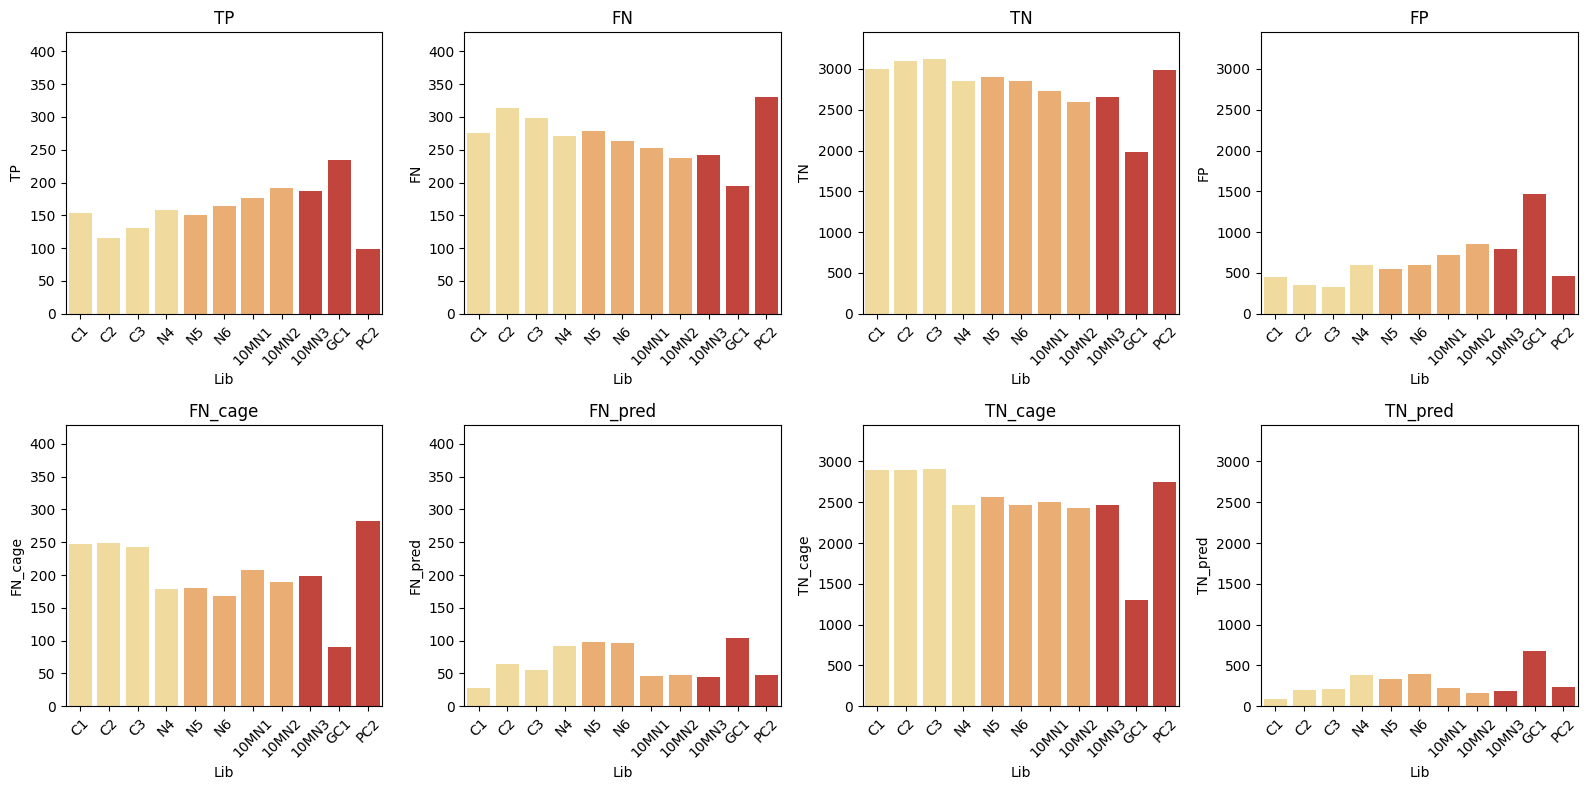

In [65]:
#### ABS DIRECTIONALITY < 0.8 ####
cfs_dl_080, pr_dl_080 = wrap_cfs_pr_plot_dl(pos_dl_mask1, neg_dl_mask1, 0.8, P, N, 1.1)

In [66]:
pr_dl_080.transpose()

,C1,C2,C3,N4,N5,N6,10MN1,10MN2,10MN3,GC1,PC2
precision,0.251645,0.247312,0.286652,0.210667,0.216643,0.217678,0.195556,0.183206,0.190234,0.137243,0.177419
recall,0.356643,0.268065,0.305361,0.368298,0.351981,0.384615,0.410256,0.447552,0.435897,0.545455,0.230769


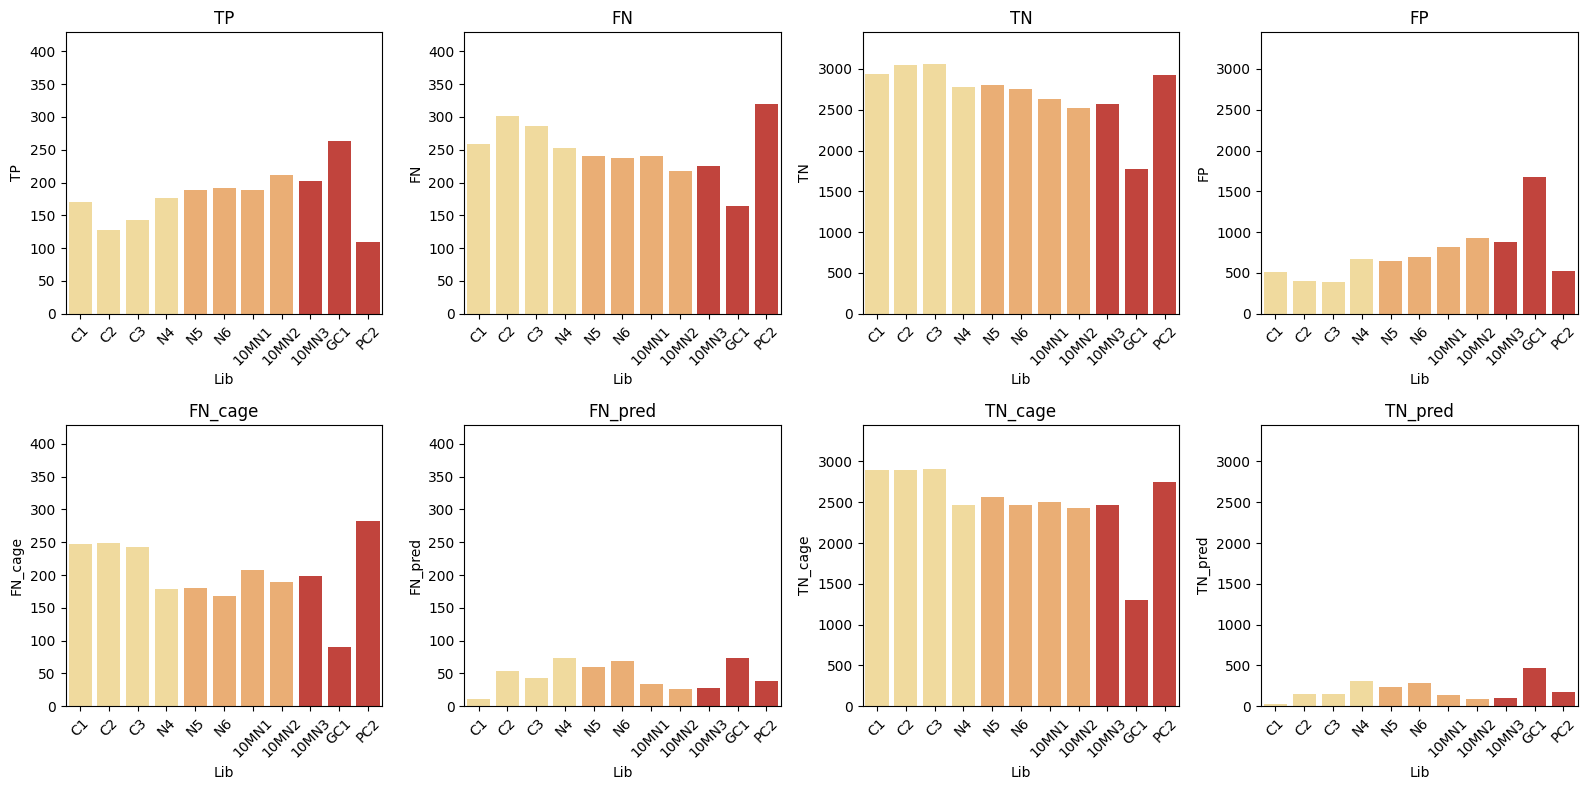

In [67]:
#### ABS DIRECTIONALITY < 0.9 ####
cfs_dl_090, pr_dl_090 = wrap_cfs_pr_plot_dl(pos_dl_mask1, neg_dl_mask1, 0.9, P, N, 1.1)

In [68]:
pr_dl_090.transpose()

,C1,C2,C3,N4,N5,N6,10MN1,10MN2,10MN3,GC1,PC2
precision,0.247813,0.242366,0.267790,0.208531,0.226619,0.215973,0.187438,0.186292,0.187269,0.135802,0.172196
recall,0.396270,0.296037,0.333333,0.410256,0.440559,0.447552,0.438228,0.494172,0.473193,0.615385,0.254079


In [69]:
#### ROC CURVE AND AUCROC ####

In [70]:
# for dl, roc can be set param pos_label=0
# however, it doesn't work for pr
# set reverse label instead [0 for positive, 1 for negative]

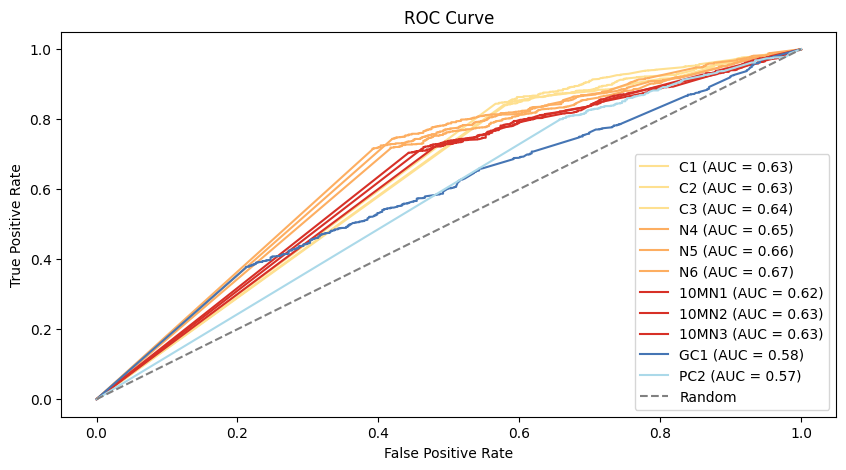

In [71]:
plot_roc_df(y_true_reverse, dl_mask1, prefer_order)

In [72]:
#### PR CURVE AND AUCPR ####

0.9514537350788452
0.951503636343594
0.9530831484701541
0.9499125170471032
0.9524366545650065
0.9520512152095825
0.9458210498159175
0.9465773675596101
0.9463306340284516
0.9282831070503899
0.9423280676196091


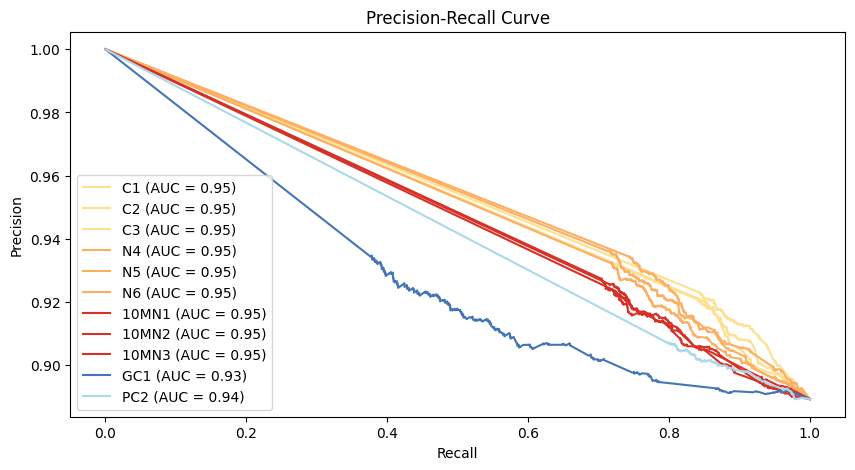

In [73]:
plot_pr_df(y_true_reverse, dl_mask1, prefer_order)

In [74]:
#### Bidir X Prediction ####

In [75]:
dlpos = pos_dl_mask1 < 0.8
predpos = pos_yproba_maskm1 >= 0.5

dlneg = neg_dl_mask1 < 0.8
predneg = neg_yproba_maskm1 >= 0.5

In [76]:
def counting_table(dl, pred):
    df = pd.DataFrame(index=dl.index, columns=dl.columns)
    df[:] = np.where((dl == True) & (pred == True), 'DL=TRUE & PRED=TRUE (T-T)',
                     np.where((dl == True) & (pred == False), 'DL=TRUE & PRED=FALSE (T-F)',
                              np.where((dl == False) & (pred == True), 'DL=FALSE & PRED=TRUE (F-T)', 'DL=FALSE & PRED=FALSE (F-F)')))
    return(df)

In [77]:
def count_occurrences(column):
    return column.value_counts()

In [78]:
ctpos = counting_table(dlpos, predpos)
result_pos = ctpos.apply(count_occurrences)
result_pos

,C1,C2,C3,N4,N5,N6,10MN1,10MN2,10MN3,GC1,PC2
DL=FALSE & PRED=FALSE (F-F),99,134,120,68,70,56,72,60,74,16,25
DL=FALSE & PRED=TRUE (F-T),177,180,178,203,208,208,181,177,168,179,305
DL=TRUE & PRED=FALSE (T-F),43,40,44,30,35,26,46,42,36,12,9
DL=TRUE & PRED=TRUE (T-T),110,75,87,128,116,139,130,150,151,222,90


In [79]:
ctneg = counting_table(dlneg, predneg)
result_neg = ctneg.apply(count_occurrences)
result_neg

,C1,C2,C3,N4,N5,N6,10MN1,10MN2,10MN3,GC1,PC2
DL=FALSE & PRED=FALSE (F-F),2112,2195,2172,1528,1635,1465,1447,1264,1338,368,629
DL=FALSE & PRED=TRUE (F-T),881,903,950,1328,1267,1390,1277,1328,1314,1609,2360
DL=TRUE & PRED=FALSE (T-F),276,203,203,255,250,250,331,364,360,225,89
DL=TRUE & PRED=TRUE (T-T),179,147,123,337,296,343,393,492,436,1246,370


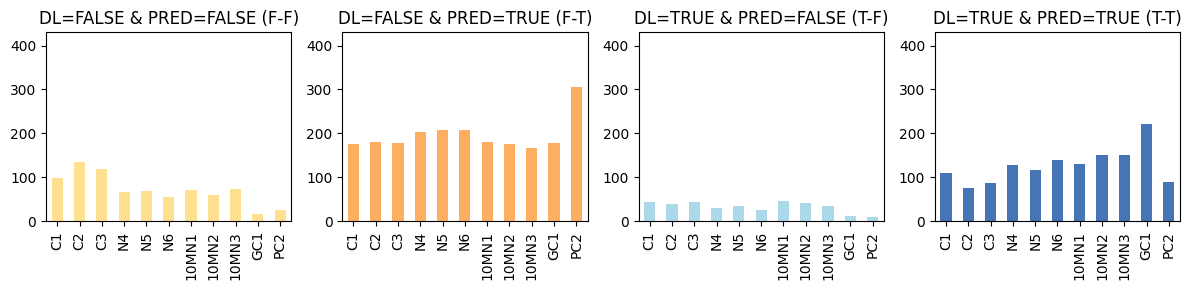

In [80]:
import pandas as pd
import matplotlib.pyplot as plt

palettes = ["#fee090", "#fdae61", "#abd9e9", "#4575b4"]

# Convert the dictionaries to dataframes
df_pos = pd.DataFrame(result_pos)

# Create subplots
fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(12, 3))

# Flatten the axes for easy indexing
axes = axes.flatten()

# Plot data for each category
for i, (category, ax) in enumerate(zip(df_pos.index, axes)):
    df_pos.loc[category].plot(kind='bar', ax=ax, color=palettes[i])
    ax.set_title(category)
    ax.set_ylim(0, 430)

# Adjust layout
plt.tight_layout()

# Show plot
plt.show()

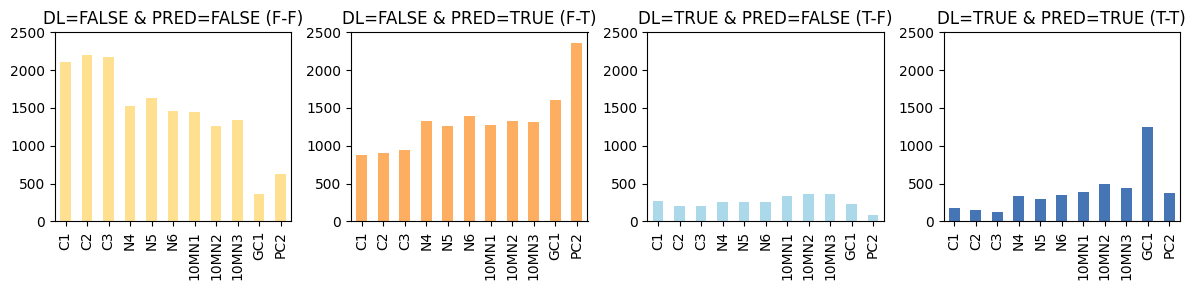

In [81]:
# Convert the dictionaries to dataframes
df_neg = pd.DataFrame(result_neg)

# Create subplots
fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(12, 3))

# Flatten the axes for easy indexing
axes = axes.flatten()

# Plot data for each category
for i, (category, ax) in enumerate(zip(df_neg.index, axes)):
    df_neg.loc[category].plot(kind='bar', ax=ax, color=palettes[i])
    ax.set_title(category)
    ax.set_ylim(0, 2500)

# Adjust layout
plt.tight_layout()

# Show plot
plt.show()

In [82]:
import plotly.express as px

In [83]:
pos_csv neg_dl_mask1 neg_yproba_maskm1

SyntaxError: invalid syntax (2772567236.py, line 1)

In [ ]:
neg_csv_slt =neg_csv[['txType', 'ovl.DHS', 'ovl.eQTL0.5']]

In [ ]:
import pandas as pd

df = pd.DataFrame(neg_csv_slt)

# Create an empty dictionary to store mappings
mappings = {}

# Factorize each column and store mappings
for col in df.columns:
    factorized, mapping = pd.factorize(df[col])
    mappings[col] = dict(zip(mapping, range(1, len(mapping) + 1)))  # Create a mapping dictionary
    df[col] = factorized + 1  # Factorize and add 1 to start from 1 instead of 0

# Display the modified DataFrame
print("Modified DataFrame:")
print(df)

# Display the mappings
print("\nMappings:")
for col, mapping in mappings.items():
    print(f"{col}: {mapping}")

In [ ]:
neg_csv_slt['dl_N'] = neg_dl_mask1['N']
neg_csv_slt['pred_N'] = neg_yproba_maskm1['N']
neg_csv_slt

In [ ]:
# Create the chart:
fig = px.parallel_coordinates(
    df, 
    color="pred_N", 
    labels={"dl_N":"dl_N", "pred_N":"pred_N", "txType": "txType","ovl.DHS": "ovl.DHS", "ovl.eQTL0.5h": "ovl.eQTL0.5", },)
    #color_continuous_scale=px.colors.diverging.Tealrose,
    #color_continuous_midpoint=2)

# Hide the color scale that is useless in this case
#fig.update_layout(coloraxis_showscale=False)

# Show the plot
fig.show()